## 336 - Accessing GOES Archives from S3

[Youtube](https://www.youtube.com/watch?v=snOmrjkEuZQ)

### GOES Data Access and Plotting

In [1]:
import xarray as xr

from datetime import datetime, timezone
from pathlib import Path
from metpy.remote import GOESArchive
from metpy.plots import ImagePlot, MapPanel, PanelContainer

In [2]:
target_time = datetime(2026, 4, 11, 22, 30, tzinfo=timezone.utc)

archive = GOESArchive(19)

prod = archive.get_product('ABI-L2-CMIPC', dt=target_time, band=2)

print(prod.name)

OR_ABI-L2-CMIPC-M6C02_G19_s20261012231181_e20261012233554_c20261012234242.nc


In [3]:
download_dir = Path('goes_data')
download_dir.mkdir(exist_ok=True)

prod.download(download_dir)
local_file = download_dir / prod.name

In [4]:
ds = xr.open_dataset(local_file)

In [5]:
ds.data_vars

Data variables:
    CMI                                               (y, x) float32 240MB ...
    DQF                                               (y, x) float32 240MB ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                            int32 4B ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    nominal_satellite_subpoint_lat                    float32 4B ...
    nominal_satellite_subpoint_lon                    float32 4B ...
    nominal_satellite_height                          float32 4B ...
    geospatial_lat_lon_extent                         float32 4B ...
    valid_pixel_count                                 float64 8B ...
    outlier_pixel_count                               float64 8B ...
    total_number_of_points                            fl

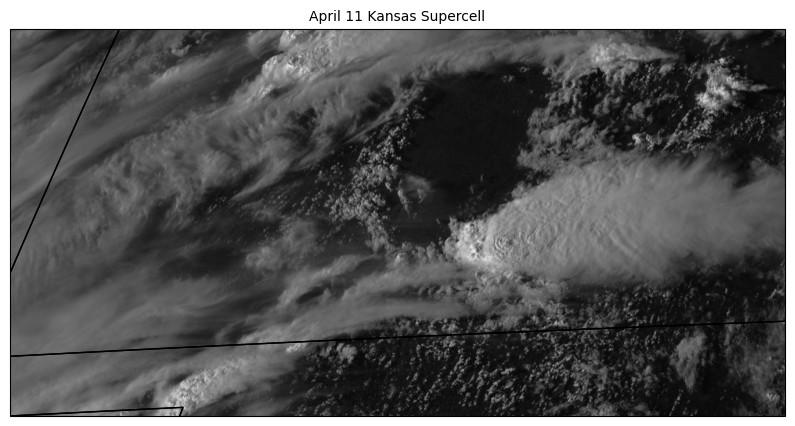

In [6]:
img = ImagePlot()
img.data = ds
img.field = 'CMI'
img.colormap = 'Greys_r'

panel = MapPanel()
panel.plots = [img]
panel.area = [-101.5, -96.0, 36.5, 39.5]
panel.layers = ['borders', 'states', 'coastline']
panel.title = 'April 11 Kansas Supercell'

pc = PanelContainer()
pc.panels = [panel]
pc.size = (10, 8)
pc.show()